# AI Product Discovery with RAG (Notebook Structure)

This notebook is the **orchestrator** for your repo-based implementation:

- `src/` holds core pipeline logic (cleaning, embeddings, FAISS, ranking, RAG, UI)
- `notebooks/` demonstrates the end-to-end workflow with plots + examples
- `data/` and `artifacts/` are **gitignored**

> **Colab tip**: If running in Colab, clone your repo and run from the repo root.


In [7]:
# Determine if running in Colab (robust, no import errors)
import sys, os

def in_colab() -> bool:
    # Safest: try importing google.colab (catch if package doesn't exist)
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        pass
    # Secondary: module already loaded
    if 'google.colab' in sys.modules:
        return True
    # Optional: environment hints
    return any(k in os.environ for k in ['COLAB_RELEASE_TAG','COLAB_GPU','COLAB_TPU_ADDR'])

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    # Optional: !pip -q install -r requirements.txt
else:
    print('Running outside Colab')


Running outside Colab


In [10]:
%%bash
export IN_COLAB=0
if python3 -c "import sys; import google.colab" &> /dev/null; then
  IN_COLAB=1
fi

if [ $IN_COLAB -eq 1 ]; then
    set -e
    # Mount Drive first (if not already)
    # python code runs before bash usually, so keep mount in Python cell above
    # Link persistent SSH config into runtime
    mkdir -p ~/.ssh
    ln -sf /content/drive/MyDrive/.ssh/id_ed25519 ~/.ssh/id_ed25519
    ln -sf /content/drive/MyDrive/.ssh/id_ed25519.pub ~/.ssh/id_ed25519.pub
    ln -sf /content/drive/MyDrive/.ssh/known_hosts ~/.ssh/known_hosts

    chmod 700 ~/.ssh
    chmod 600 ~/.ssh/id_ed25519
    chmod 644 ~/.ssh/id_ed25519.pub

    echo "SSH ready."

    git config --global user.name "Zhan"
    git config --global user.email "shizhe_zhang@berkeley.edu"
    ssh -T git@github.com || true
fi

In [11]:
# Ensure repo root is on sys.path so `import src.*` works
from pathlib import Path

cwd = Path.cwd()

# If running from repo root, keep it; if from notebooks/, go up one level
if (cwd / 'src').exists():
    repo_root = cwd
elif (cwd.name == 'notebooks') and ((cwd.parent / 'src').exists()):
    repo_root = cwd.parent
else:
    # Fallback: search upwards for a folder containing `src` and `requirements.txt`
    candidates = [cwd, *cwd.parents]
    repo_root = next((p for p in candidates if (p / 'src').exists()), cwd)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('Repo root:', repo_root)
print('CWD:', cwd)
print('sys.path[0]:', sys.path[0])


Repo root: /Users/zhangshizhe/Dropbox/UCB/Pyramyd
CWD: /Users/zhangshizhe/Dropbox/UCB/Pyramyd/notebooks
sys.path[0]: /Users/zhangshizhe/Dropbox/UCB/Pyramyd


In [3]:
# (Colab) If you cloned your repo, run this cell from the repo root.
# Example:
# !git clone git@github.com:<YOU>/<REPO>.git
# %cd <REPO>

# Install dependencies (Colab-only). Locally, use: pip install -r requirements.txt
# !pip -q install -r requirements.txt

import os, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo modules
from src.config import EMBED_MODEL, LLM_MODEL, ARTIFACT_DIR
from src.data import load_data

# Uncomment as you implement these modules
# from src.embeddings import embed_texts
# from src.index import build_index
# from src.ranker import hybrid_score
# from src.rag import build_prompt

os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("EMBED_MODEL:", EMBED_MODEL)
print("LLM_MODEL:", LLM_MODEL)
print("ARTIFACT_DIR:", ARTIFACT_DIR)


EMBED_MODEL: sentence-transformers/all-MiniLM-L6-v2
LLM_MODEL: google/gemma-2b-it
ARTIFACT_DIR: artifacts


## 2) Load CSV + Inspect


In [14]:
# Path options:
# - In Colab: upload to /content, or mount Google Drive
# - Locally: point to your local file

CSV_PATH = "../data/company_reviews.csv"  # TODO: change to your file path

df_raw = load_data(CSV_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head(3))

# Quick schema + missingness
col_info = pd.DataFrame({
    "col": df_raw.columns,
    "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "missing_%": [df_raw[c].isna().mean()*100 for c in df_raw.columns],
}).sort_values("missing_%", ascending=False)

display(col_info)


Shape: (17050, 20)


,name,rating,reviews,description,happiness,ceo_approval,ceo_count,ratings,locations,roles,salary,interview_experience,interview_difficulty,interview_duration,interview_count,headquarters,employees,industry,revenue,website
0,Sitel,NaN,NaN,"Sitel Group’s 75,000 people across the globe c...","{'Work Happiness Score': '55', 'Achievement': ...",70%,"CEO Approval is based on 4,612 ratings","{'Work/Life Balance': '3.4', 'Compensation/Ben...","{'Paradise, NV': '5.0', 'Pioneer, OH': '4.7', ...","{'Tier 1 Agent': '5.0', 'Director of Operation...",{'Customer Service Representative': '$14.48 pe...,Favorable,Easy,About a day or two,Based on 645 interviews,"600 Brickell Ave Miami, FL 33131 Vereinigte St...","10,000+",Telecommunications,$1B to $5B (USD),Twitter\nFacebook\nSitel website
1,Meadowbrook Rehabilitation,3.7,21 reviews,You'll work with the most experienced and loya...,{},NaN,NaN,"{'Work/Life Balance': '4.1', 'Compensation/Ben...",{},{},{},Favorable,Easy,NaN,Based on 5 interviews,Illinois,NaN,Healthcare,NaN,Meadowbrook Rehabilitation website
2,Intermountain,4.0,23 reviews,Why Intermountain?\n\nWe Bring Hope\n\nWith ou...,{},88%,CEO Approval is based on 17 ratings,"{'Work/Life Balance': '3.5', 'Compensation/Ben...",{},{},{'Mental Health Technician': '$13.16 per hour'...,Favorable,Medium,About a day or two,Based on 8 interviews,"Headquarters: 3240 Dredge Dr. Helena, MT 59602",201 to 500,Healthcare,$5M to $25M (USD),Twitter\nFacebook\nIntermountain website


,col,dtype,missing_%
18,revenue,object,40.310850
13,interview_duration,object,39.460411
5,ceo_approval,object,34.181818
6,ceo_count,object,34.181818
12,interview_difficulty,object,32.774194
14,interview_count,object,32.557185
11,interview_experience,object,32.557185
16,employees,object,11.888563
17,industry,object,10.826979
15,headquarters,object,10.674487


## 3) Cleaning & Parsing


In [17]:
# TODO: Prefer moving these into src/data.py as you finalize.
# For now, implement minimal inline cleaning so notebook runs.

def to_float(x):
    try:
        if pd.isna(x): return np.nan
        s = str(x).strip().replace("%","")
        return float(s)
    except Exception:
        return np.nan

def parse_listish(x):
    if pd.isna(x): return []
    if isinstance(x, list): return x
    s = str(x).strip()
    if not s: return []
    if s.startswith("[") and s.endswith("]"):
        try:
            obj = json.loads(s)
            if isinstance(obj, list):
                return [str(t).strip() for t in obj if str(t).strip()]
        except Exception:
            pass
    for sep in [";", "|", ","]:
        if sep in s:
            return [t.strip() for t in s.split(sep) if t.strip()]
    return [s]

def parse_salary(x):
    # Returns (min, max, median) from strings like "$90k-$120k"
    if pd.isna(x): 
        return (np.nan, np.nan, np.nan)
    s = str(x).lower().replace("$","").replace("usd","").strip()
    s = s.replace("k","000")
    nums = re.findall(r"([0-9][0-9,]*)", s)
    nums = [float(n.replace(",","")) for n in nums] if nums else []
    if len(nums) == 0:
        return (np.nan, np.nan, np.nan)
    if len(nums) == 1:
        return (nums[0], nums[0], nums[0])
    mn, mx = min(nums), max(nums)
    return (mn, mx, (mn+mx)/2)

df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]

# Numeric columns (edit as needed)
for c in ["rating", "happiness", "ceo_approval", "interview_difficulty", "interview_experience"]:
    if c in df.columns:
        df[c] = df[c].apply(to_float)

# List-like columns (edit as needed)
for c in ["roles", "locations", "ratings"]:
    if c in df.columns:
        df[c] = df[c].apply(parse_listish)

# Salary parsing
if "salary" in df.columns:
    parsed = df["salary"].apply(parse_salary)
    df["salary_min"] = [t[0] for t in parsed]
    df["salary_max"] = [t[1] for t in parsed]
    df["salary_median"] = [t[2] for t in parsed]

# Build doc text
text_cols = [c for c in ["description", "reviews"] if c in df.columns]
df["doc_text"] = df[text_cols].fillna("").astype(str).agg("\n".join, axis=1).str.replace(r"\s+"," ", regex=True).str.strip()

df_clean = df
print("Clean shape:", df_clean.shape)
display(df_clean.head())


Clean shape: (17050, 24)


,name,rating,reviews,description,happiness,ceo_approval,ceo_count,ratings,locations,roles,...,interview_count,headquarters,employees,industry,revenue,website,salary_min,salary_max,salary_median,doc_text
0,Sitel,NaN,NaN,"Sitel Group’s 75,000 people across the globe c...",NaN,70.0,"CEO Approval is based on 4,612 ratings","[{'Work/Life Balance': '3.4', 'Compensation/Be...","[{'Paradise, NV': '5.0', 'Pioneer, OH': '4.7',...","[{'Tier 1 Agent': '5.0', 'Director of Operatio...",...,Based on 645 interviews,"600 Brickell Ave Miami, FL 33131 Vereinigte St...","10,000+",Telecommunications,$1B to $5B (USD),Twitter\nFacebook\nSitel website,11.0,72.0,41.5,"Sitel Group’s 75,000 people across the globe c..."
1,Meadowbrook Rehabilitation,3.7,21 reviews,You'll work with the most experienced and loya...,NaN,NaN,NaN,"[{'Work/Life Balance': '4.1', 'Compensation/Be...",[{}],[{}],...,Based on 5 interviews,Illinois,NaN,Healthcare,NaN,Meadowbrook Rehabilitation website,NaN,NaN,NaN,You'll work with the most experienced and loya...
2,Intermountain,4.0,23 reviews,Why Intermountain?\n\nWe Bring Hope\n\nWith ou...,NaN,88.0,CEO Approval is based on 17 ratings,"[{'Work/Life Balance': '3.5', 'Compensation/Be...",[{}],[{}],...,Based on 8 interviews,"Headquarters: 3240 Dredge Dr. Helena, MT 59602",201 to 500,Healthcare,$5M to $25M (USD),Twitter\nFacebook\nIntermountain website,13.0,42659.0,21336.0,Why Intermountain? We Bring Hope With our holi...
3,Smith & Nephew,NaN,NaN,It's more than business at Smith+Nephew - it's...,NaN,76.0,CEO Approval is based on 374 ratings,"[{'Work/Life Balance': '3.5', 'Compensation/Be...","[{'Largo, FL': '4.5', 'Chicago, IL': '4.3', 'S...","[{'Packaging Technician': '5.0', 'Senior Assoc...",...,Based on 116 interviews,"Building 5, Croxley Park, Hatters Lane, Watfor...","10,000+",Healthcare,$1B to $5B (USD),Twitter\nFacebook\nSmith & Nephew website,0.0,53031.0,26515.5,It's more than business at Smith+Nephew - it's...
4,Reverse Mortgage Funding,4.1,19 reviews,Reverse Mortgage Funding LLC is committed to e...,NaN,NaN,NaN,"[{'Work/Life Balance': '4.2', 'Compensation/Be...",[{}],[{}],...,Based on 5 interviews,Bloomfield,11 to 50,Financial Services,$5M to $25M (USD),Reverse Mortgage Funding website,NaN,NaN,NaN,Reverse Mortgage Funding LLC is committed to e...


In [18]:
print(df['name'])

0                                     Sitel
1                Meadowbrook Rehabilitation
2                             Intermountain
3                            Smith & Nephew
4                  Reverse Mortgage Funding
                        ...                
17045                    Billion Automotive
17046                      ScienceLogic Inc
17047                        Northland PACE
17048                        Lloyd Staffing
17049    North Star Insurance Advisors, LLC
Name: name, Length: 17050, dtype: object


## 4) Quick EDA


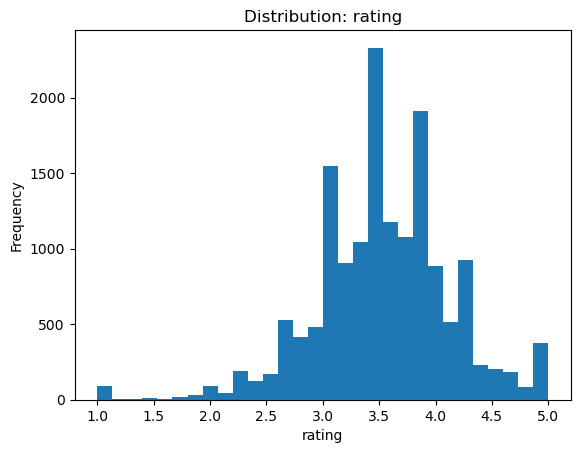

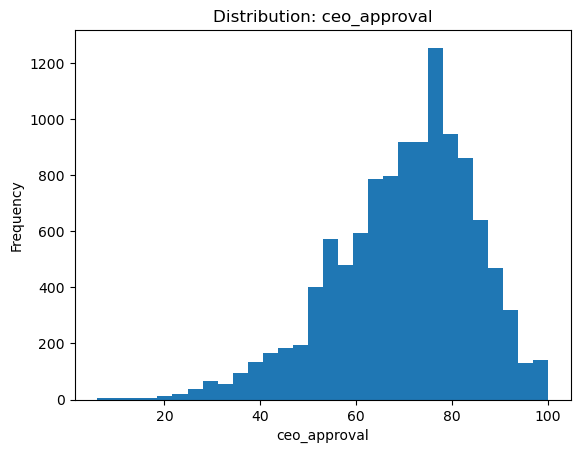

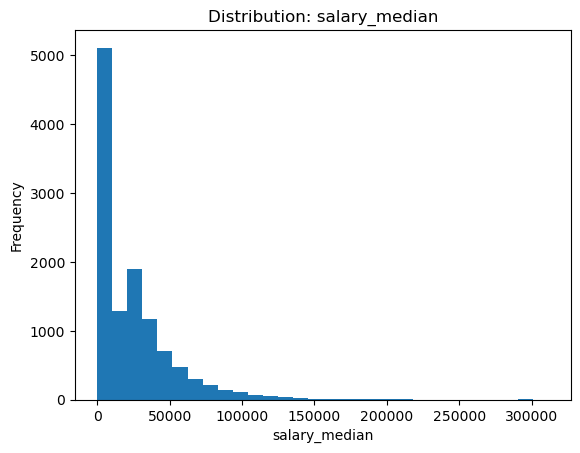

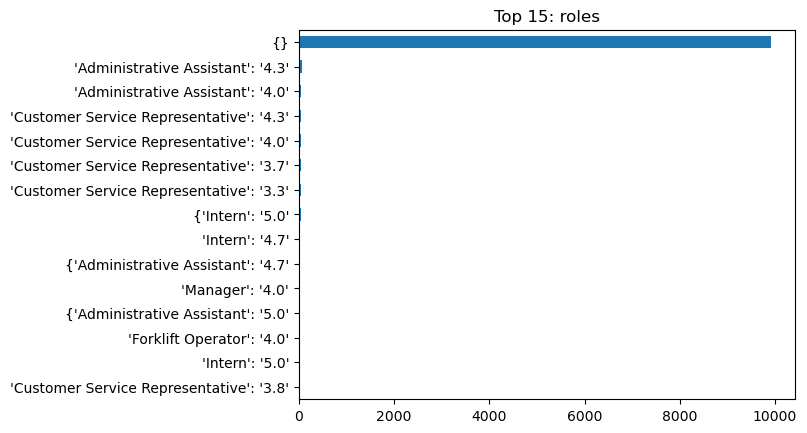

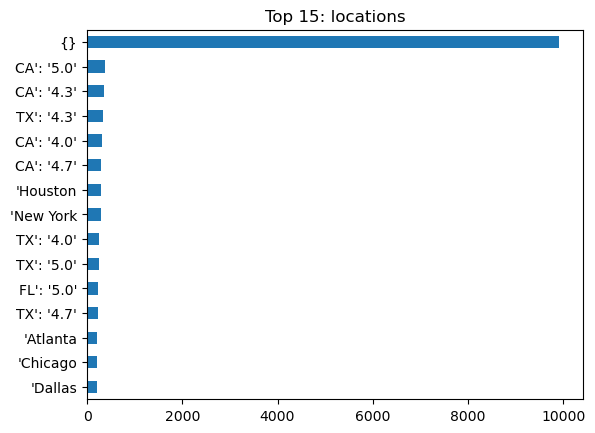

In [19]:
# Keep EDA tight (4–6 plots max). Add/remove columns based on your data.

def hist_if_exists(col):
    if col in df_clean.columns and df_clean[col].notna().any():
        plt.figure()
        df_clean[col].dropna().plot(kind="hist", bins=30, title=f"Distribution: {col}")
        plt.xlabel(col)
        plt.show()

for col in ["rating", "happiness", "ceo_approval", "salary_median"]:
    hist_if_exists(col)

# Top roles / locations (optional)
def top_k_listcol(col, k=15):
    if col not in df_clean.columns:
        return None
    items = []
    for lst in df_clean[col]:
        items.extend(lst if isinstance(lst, list) else [])
    s = pd.Series(items).value_counts().head(k)
    plt.figure()
    s.sort_values().plot(kind="barh", title=f"Top {k}: {col}")
    plt.show()
    return s

_ = top_k_listcol("roles", k=15)
_ = top_k_listcol("locations", k=15)


## 5) Build Retrieval Documents


In [20]:
# Define retrieval unit: start with 1 row -> 1 document.

NAME_COL = "name" if "name" in df_clean.columns else df_clean.columns[0]

def build_docs(df):
    docs = []
    for i, row in df.iterrows():
        meta = {"row_index": int(i), "company": str(row.get(NAME_COL, i))}
        # Keep a few structured signals for ranking/filters
        for c in ["rating","happiness","ceo_approval","salary_median","salary_min","salary_max","roles","locations"]:
            if c in df.columns:
                meta[c] = row.get(c)
        docs.append({"id": str(i), "text": str(row.get("doc_text","")), "meta": meta})
    return docs

docs = build_docs(df_clean)
print("Docs:", len(docs))
print("Example meta:", docs[0]["meta"])
print("Example text preview:", docs[0]["text"][:240])


Docs: 17050
Example meta: {'row_index': 0, 'company': 'Sitel', 'rating': nan, 'happiness': nan, 'ceo_approval': 70.0, 'salary_median': 41.5, 'salary_min': 11.0, 'salary_max': 72.0, 'roles': ["{'Tier 1 Agent': '5.0'", "'Director of Operations': '4.7'", "'Senior Vice President': '4.7'", "'Director of Finance': '4.7'", "'Sitel': '4.5'}"], 'locations': ["{'Paradise", "NV': '5.0'", "'Pioneer", "OH': '4.7'", "'Morocco", "IN': '4.6'", "'Kingston", "NY': '4.6'", "'Bartlett", "TN': '4.4'}"]}
Example text preview: Sitel Group’s 75,000 people across the globe connect many of the world’s best-known brands with their customers - 3.5 million times every day. As a global customer experience (CX) management leader, we apply our 30+ years of industry-leadin


## 6) Embeddings


In [21]:
# Build embeddings for retrieval
# (Works locally + in Colab)

from src.embeddings import embed_texts

texts = [d["text"] or " " for d in docs]
emb = embed_texts(texts, EMBED_MODEL)

emb_path = os.path.join(ARTIFACT_DIR, "embeddings.npy")
np.save(emb_path, emb)

print("Embeddings:", emb.shape)
print("Saved:", emb_path)


/opt/homebrew/Caskroom/miniconda/base/envs/rag/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embeddings: (17050, 384)
Saved: artifacts/embeddings.npy


## 7) FAISS Index


In [ ]:
# Build & persist FAISS index

from src.index import build_index
import faiss

index = build_index(emb)
index_path = os.path.join(ARTIFACT_DIR, "faiss.index")
faiss.write_index(index, index_path)

print("FAISS ntotal:", index.ntotal)
print("Saved:", index_path)


## 8) Retrieval + Filters Demo


In [ ]:
# Retrieval + optional metadata filters demo

from typing import Optional, Any


def _contains_any(haystack: Any, needles: list[str]) -> bool:
    if haystack is None:
        return False
    if isinstance(haystack, str):
        hs = haystack.lower()
        return any(n.lower() in hs for n in needles)
    if isinstance(haystack, list):
        hs = " ".join([str(x).lower() for x in haystack])
        return any(n.lower() in hs for n in needles)
    return False


def search(query: str, top_k: int = 10, filters: Optional[dict] = None):
    """Return a list of {score, doc}.

    filters supports (all optional):
      - location: str or list[str]
      - role: str or list[str]
      - min_salary: float
      - min_rating: float
    """
    filters = filters or {}

    q_emb = embed_texts([query], EMBED_MODEL)
    D, I = index.search(q_emb, top_k * 5)  # over-retrieve before filtering

    results = []
    for score, idx in zip(D[0].tolist(), I[0].tolist()):
        if idx < 0:
            continue
        d = docs[idx]
        meta = d.get("meta", {}) or {}

        # Filters
        loc = filters.get("location")
        role = filters.get("role")
        min_salary = filters.get("min_salary")
        min_rating = filters.get("min_rating")

        if loc is not None:
            loc_list = [loc] if isinstance(loc, str) else list(loc)
            if not _contains_any(meta.get("locations"), loc_list):
                continue

        if role is not None:
            role_list = [role] if isinstance(role, str) else list(role)
            if not _contains_any(meta.get("roles"), role_list):
                continue

        if min_salary is not None:
            sal = meta.get("salary_median")
            if sal is None or (isinstance(sal, float) and np.isnan(sal)) or float(sal) < float(min_salary):
                continue

        if min_rating is not None:
            rating = meta.get("rating")
            if rating is None or (isinstance(rating, float) and np.isnan(rating)) or float(rating) < float(min_rating):
                continue

        results.append({"score": float(score), "doc": d})
        if len(results) >= top_k:
            break

    return results


# Demo
query = "Which companies have great culture and work-life balance?"
hits = search(query, top_k=5, filters=None)
print("Hits:", len(hits))
for i, h in enumerate(hits, start=1):
    meta = h["doc"].get("meta", {})
    print(f"{i}. score={h['score']:.3f} company={meta.get('company')} row={meta.get('row_index')}")


## 9) Hybrid Ranking with User Priorities


In [ ]:
# TODO:
# - Normalize structured columns (salary_median, rating, happiness, etc.)
# - Combine with semantic similarity using weights from user priorities
# - Output a ranked table

# Example priorities:
# priorities = {"salary_median":0.4, "rating":0.3, "happiness":0.3}

raise NotImplementedError("Implement ranker (suggest: src/ranker.py), then run ranking experiments here.")


## 10) RAG Answer Generation (Grounded)


In [ ]:
# RAG Answer Generation (Grounded) using Qwen Instruct
# Tip (Colab): uncomment installs if needed
# !pip -q install -U transformers accelerate bitsandbytes

from src.rag import load_llm, generate_answer, format_citations

# Good default for free Colab GPUs. Alternatives:
# - "Qwen/Qwen2.5-0.5B-Instruct" (fastest)
# - "Qwen/Qwen2.5-1.5B-Instruct" (good balance)
# - "Qwen/Qwen2.5-3B-Instruct" (needs more VRAM; prefer 4-bit)
QWEN_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

model, tokenizer = load_llm(QWEN_MODEL, use_4bit=True)

query = "Recommend 3 companies with high happiness and good work-life balance. Explain why with citations."
retrieved = search(query, top_k=6, filters={"min_rating": 3.5})
ctx_docs = [r["doc"] for r in retrieved]

answer = generate_answer(
    query,
    ctx_docs,
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=400,
    temperature=0.2,
)

print(answer)
print("\n---\nCitations legend:\n" + format_citations(ctx_docs))


## 11) Side-by-Side Comparison


In [ ]:
# TODO:
# - Select top N or user-selected companies
# - Create a structured comparison table
# - Ask LLM for a comparison summary (salary-first vs culture/WLB-first) with citations

raise NotImplementedError("Implement comparison utilities (suggest: src/compare.py), then run comparison here.")


## 12) Lightweight Evaluation


In [ ]:
# TODO:
# - Create a small set of test queries (10–30)
# - Log retrieval results and qualitative judgment
# - Optional: weak supervision Recall@K (if you can derive a 'ground truth' from metadata)

raise NotImplementedError("Implement eval (suggest: src/eval.py), then summarize metrics here.")


## 13) Gradio Demo UI


In [ ]:
# TODO:
# - Implement `build_app()` in src/ui.py returning a gradio Blocks app
# - UI should support:
#   - query box
#   - sliders for priorities
#   - optional role/location filters
#   - results table + RAG explanation

# Example:
# from src.ui import build_app
# demo = build_app()
# demo.launch(share=True)

raise NotImplementedError("Implement src/ui.py -> build_app(), then launch here.")


## 14) Save Artifacts + Local Run Notes


In [ ]:
# Optional artifact bundling:
# import shutil
# shutil.make_archive("artifacts_bundle", "zip", ARTIFACT_DIR)
# print("Created artifacts_bundle.zip")


## 15) Resume Bullets & Next Steps

- Built a RAG-based product discovery engine with FAISS semantic search over company reviews + metadata.
- Designed a hybrid ranking model combining embedding similarity with structured signals and user-weighted priorities.
- Deployed an interactive Gradio UI enabling natural-language search, filtering, and AI side-by-side comparisons with citations.
